# Guesthouse Revenue & Booking Analytics
### A synthetic hospitality portfolio reconstruction

> This project is a portfolio reconstruction inspired by real hospitality analytics work. All booking records and financial values are synthetic and do not represent the actual guesthouse's confidential data.

**Decision context:** a four-room independent guesthouse wants to understand when rooms sell, which room types contribute revenue, and where to test pricing changes. This walkthrough moves from an imperfect booking export to validated metrics and cautious business recommendations.

**Scope:** 2023–2025 · 4 rooms · synthetic EUR · one room per booking · no external data.

The original business data and code are unavailable. These are newly created analytical examples, not historical company results.

## 1. Set up the analysis

Run from the repository root or `notebooks/`. The raw CSV is committed, so this notebook can be executed after installing `requirements-notebook.txt`. It uses the same functions as the command-line pipeline.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start the notebook from the repository root or notebooks directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.clean_data import clean_bookings
from src.config import DATA_DIR, FIGURES_DIR, ROOM_COUNTS
from src.kpi_analysis import (
    annual_performance, build_room_nights, calculate_kpis, daily_performance,
    monthly_performance, room_performance,
)
from src.pricing_analysis import business_insights, pricing_tables
from src.seasonality_analysis import seasonality_tables
from src.visualizations import create_visualizations
from src.validation import validate_guesthouse
from src.run_analysis import annual_summary_markdown

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
print("Synthetic inventory:", ROOM_COUNTS)
print("Reporting period: 2023-01-01 through 2025-12-31")

Synthetic inventory: {'Standard Double': 1, 'Twin Room': 1, 'Family Room': 1, 'Superior Double': 1}
Reporting period: 2023-01-01 through 2025-12-31


## 2. Inspect the synthetic export

The simulation uses seed 42 for bookings and seed 43 for controlled export problems. It is calibrated to approximately €25,000–€35,000 annual room revenue, centered near €30,000, and 40–60% annual occupancy. These are synthetic scale targets, not confidential business figures. Nightly quotes range from €30–€65, and revenue is derived only from completed stays; no annual revenue total is assigned. It includes seasonal demand, room-type prices, weekend effects, varied lead times and cancellations. It enforces individual room availability for completed stays.

The raw file intentionally contains duplicate rows, category whitespace/casing, missing guest counts and incorrect derived fields. First inspect missingness, data types and a few artificial records.

In [2]:
raw = pd.read_csv(DATA_DIR / "synthetic_bookings.csv")
print(f"Raw rows: {len(raw):,}; exact duplicate rows: {raw.duplicated().sum():,}")
display(raw.head())
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing_values": raw.isna().sum()}))

Raw rows: 799; exact duplicate rows: 7


,booking_id,booking_date,check_in,check_out,room_id,room_type,guests,nights,room_rate,revenue,booking_channel,booking_status,lead_time
0,SYN-B000001,2022-11-27,2023-01-05,2023-01-09,SYN-TWI-01,Twin Room,1.00,4,31.91,127.64,Online travel agency,Completed,39
1,SYN-B000002,2022-12-15,2023-01-05,2023-01-06,SYN-FAM-01,Family Room,2.00,1,36.03,36.03,Online travel agency,Completed,21
2,SYN-B000003,2022-12-12,2023-01-06,2023-01-08,SYN-SUP-01,Superior Double,1.00,2,42.73,85.46,Online travel agency,Completed,25
3,SYN-B000004,2023-01-01,2023-01-09,2023-01-14,SYN-FAM-01,Family Room,2.00,5,37.54,187.70,direct,Completed,8
4,SYN-B000005,2022-12-31,2023-01-12,2023-01-14,SYN-STA-01,Standard Double,2.00,2,30.49,60.98,Online travel agency,Completed,12


,dtype,missing_values
booking_id,str,0
booking_date,str,0
check_in,str,0
check_out,str,0
room_id,str,0
room_type,str,0
guests,float64,7
nights,int64,0
room_rate,float64,0
revenue,float64,0


## 3. Clean and validate

Normalize categories, remove exact duplicate records, validate source dates and rates, and recompute nights, lead time and revenue. Conflicting booking IDs or invalid source values raise errors. Missing guest counts remain unknown because room-based KPIs do not require them.

Cancelled bookings remain in the dataset to measure cancellation rate, but contribute zero revenue and zero occupied room nights.

In [3]:
bookings, quality = clean_bookings(raw)
display(pd.Series(quality, name="Cleaning audit").to_frame())
display(bookings[["nights", "room_rate", "revenue", "lead_time", "guests"]].describe().round(2))
display(pd.crosstab(bookings["booking_channel"], bookings["booking_status"], margins=True))

,Cleaning audit
input_rows,799
normalized_category_cells,45
duplicate_rows_removed,7
missing_guests_retained,7
nights_values_rebuilt,7
lead_time_values_rebuilt,7
revenue_values_rebuilt,7
output_rows,792


,nights,room_rate,revenue,lead_time,guests
count,792.00,792.00,792.00,792.00,785.00
mean,3.01,43.65,115.13,28.45,1.76
std,1.51,6.84,84.86,27.85,0.82
min,1.00,30.16,0.00,1.00,1.00
25%,2.00,38.15,45.84,11.00,1.00
50%,3.00,43.28,107.92,20.00,2.00
75%,4.00,48.60,157.90,36.00,2.00
max,9.00,61.27,420.48,180.00,4.00


booking_status,Cancelled,Completed,All
booking_channel,,,
Direct,26,302,328
Online travel agency,72,311,383
Travel agent,15,66,81
All,113,679,792


## 4. Build the correct calendar denominator

Occupancy is sold room nights divided by available room nights. With four rooms open every day, capacity is **4,384 room nights**: 1,460 in 2023, 1,464 in leap year 2024 and 1,460 in 2025. A full calendar retains dates with no sales.

Expand each completed stay from check-in through the night before checkout. This assigns a cross-month stay to the months where the nights occurred. The quoted nightly rate is fixed within a stay. Cancellation fees, commissions, taxes and other revenue are not modeled.

In [4]:
nightly = build_room_nights(bookings)
daily = daily_performance(nightly)
kpis = calculate_kpis(bookings, nightly)
annual = annual_performance(bookings, daily)
validation = validate_guesthouse(bookings, nightly, daily, annual)
display(pd.Series(validation["checks"], name="Passed").to_frame())

assert daily["available_room_nights"].sum() == 4_384
assert (daily["room_nights"] <= daily["available_room_nights"]).all()
assert not nightly.duplicated(["room_id", "stay_date"]).any()
assert np.isclose(nightly["nightly_revenue"].sum(), bookings["revenue"].sum())
print("Revenue reconciliation and capacity checks passed.")

cross_month = bookings.loc[
    bookings["booking_status"].eq("Completed")
    & bookings["check_in"].dt.to_period("M").ne(
        (bookings["check_out"] - pd.Timedelta(days=1)).dt.to_period("M")
    )
].iloc[0]
display(nightly.loc[nightly["booking_id"].eq(cross_month["booking_id"])])

,Passed
exactly_four_physical_rooms,True
valid_room_types,True
maximum_four_occupied_rooms_per_night,True
no_overlapping_completed_bookings,True
four_available_room_nights_every_day,True
correct_annual_capacity,True
annual_revenue_in_target_range,True
annual_occupancy_in_target_range,True
nightly_rates_in_guesthouse_range,True
revenue_equals_rate_times_completed_nights,True


Revenue reconciliation and capacity checks passed.


,booking_id,room_id,room_type,stay_date,nightly_revenue
27,SYN-B000012,SYN-FAM-01,Family Room,2023-01-29,36.24
28,SYN-B000012,SYN-FAM-01,Family Room,2023-01-30,36.24
29,SYN-B000012,SYN-FAM-01,Family Room,2023-01-31,36.24
30,SYN-B000012,SYN-FAM-01,Family Room,2023-02-01,36.24
31,SYN-B000012,SYN-FAM-01,Family Room,2023-02-02,36.24
32,SYN-B000012,SYN-FAM-01,Family Room,2023-02-03,36.24
33,SYN-B000012,SYN-FAM-01,Family Room,2023-02-04,36.24


## 5. Review the headline KPIs

**ADR** = completed revenue / sold room nights. **RevPAR** = revenue / available room nights. **Average stay and lead time** use completed bookings; **cancellation rate** uses all unique bookings. Rate metrics are ratios of totals, not averages of monthly ratios. Annual financial measures use stay year; counts, cancellation rate and full average stay length use check-in year. Cancelled requests contribute no occupied nights or revenue.

In [5]:
summary = {
    "Room revenue (EUR)": f"€{kpis['total_revenue']:,.2f}",
    "Unique bookings": f"{kpis['total_bookings']:,}",
    "Completed / cancelled bookings": f"{kpis['completed_bookings']:,} / {kpis['cancelled_bookings']:,}",
    "Sold / available room nights": f"{kpis['room_nights']:,} / {kpis['available_room_nights']:,}",
    "ADR (EUR)": f"€{kpis['adr']:.2f}",
    "Occupancy": f"{kpis['occupancy_rate']:.1%}",
    "RevPAR (EUR)": f"€{kpis['revpar']:.2f}",
    "Average completed stay (nights)": f"{kpis['average_length_of_stay']:.2f}",
    "Cancellation rate": f"{kpis['cancellation_rate']:.1%}",
    "Average completed booking lead time (days)": f"{kpis['average_lead_time']:.1f}",
}
display(pd.Series(summary, name="Result").to_frame())

display(Markdown(annual_summary_markdown(annual)))

tables = {
    "annual_performance": annual,
    "monthly_performance": monthly_performance(bookings, daily),
    "room_performance": room_performance(bookings, daily),
    **seasonality_tables(bookings, daily),
}
tables.update(pricing_tables(bookings, daily, tables["monthly_performance"]))
create_visualizations(bookings, tables)

,Result
Room revenue (EUR),"€91,183.12"
Unique bookings,792
Completed / cancelled bookings,679 / 113
Sold / available room nights,"2,044 / 4,384"
ADR (EUR),€44.61
Occupancy,46.6%
RevPAR (EUR),€20.80
Average completed stay (nights),3.01
Cancellation rate,14.3%
Average completed booking lead time (days),28.8


| Year | Revenue (EUR) | Occupied room nights | Available room nights | Occupancy | ADR (EUR) | All bookings | Completed | Avg. stay (nights) | Cancellation rate |
|:--|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| 2023 | €29,476.66 | 674 | 1,460 | 46.2% | €43.73 | 264 | 227 | 2.97 | 14.0% |
| 2024 | €30,262.17 | 679 | 1,464 | 46.4% | €44.57 | 274 | 231 | 2.94 | 15.7% |
| 2025 | €31,444.29 | 691 | 1,460 | 47.3% | €45.51 | 254 | 221 | 3.12 | 13.0% |

Revenue and occupied (booked) room nights use stay year and exclude cancellations. Booking counts, average full stay length and cancellation rates use check-in year. 2024 includes leap day.


## 6. Explore monthly revenue, ADR and occupancy

Monthly financial measures use stay nights; booking counts use the arrival month. These are different business questions and need different date definitions. The seasonal pattern is intentionally programmed, while the exact monthly outcomes come from random simulated bookings.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,total_bookings,completed_bookings,cancelled_bookings
month,,,,,,,,,
2023-01,"1,068.78",30,124,35.63,0.24,8.62,12,11,1
2023-02,741.03,20,112,37.05,0.18,6.62,10,9,1
2023-03,"1,234.33",34,124,36.30,0.27,9.95,15,13,2
2023-04,"1,860.35",48,120,38.76,0.40,15.50,25,21,4
2023-05,"2,069.58",52,124,39.80,0.42,16.69,28,22,6
2023-06,"4,728.34",98,120,48.25,0.82,39.40,30,28,2
2023-07,"4,782.99",101,124,47.36,0.81,38.57,29,27,2
2023-08,"4,716.31",96,124,49.13,0.77,38.03,30,24,6
2023-09,"4,093.69",84,120,48.73,0.70,34.11,31,27,4


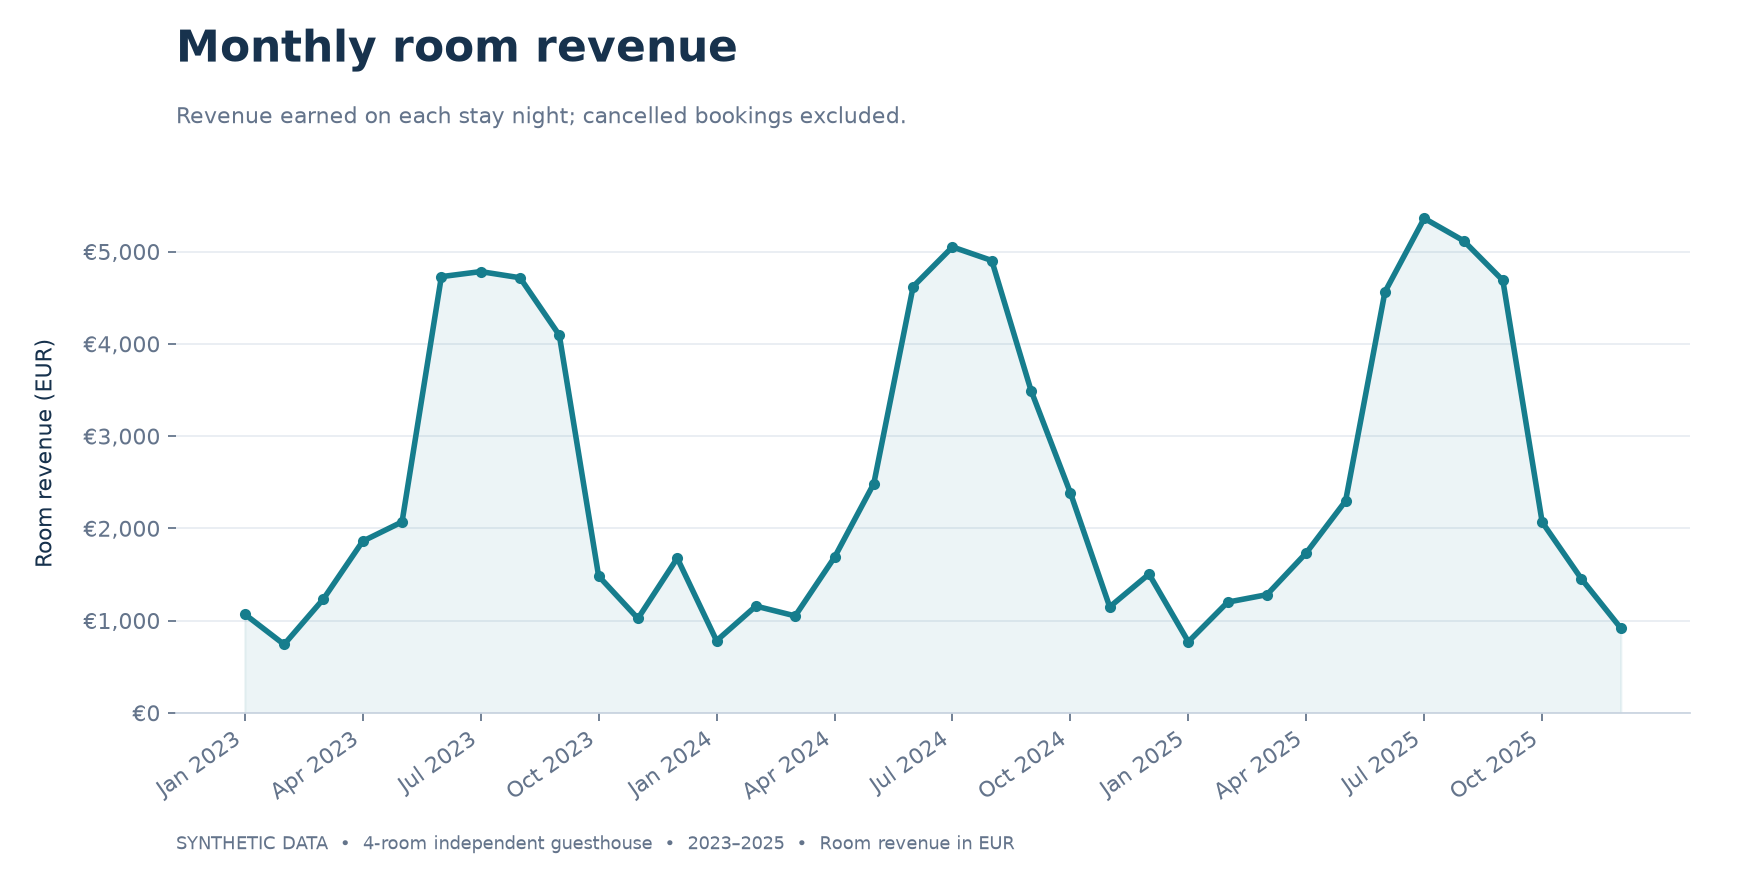

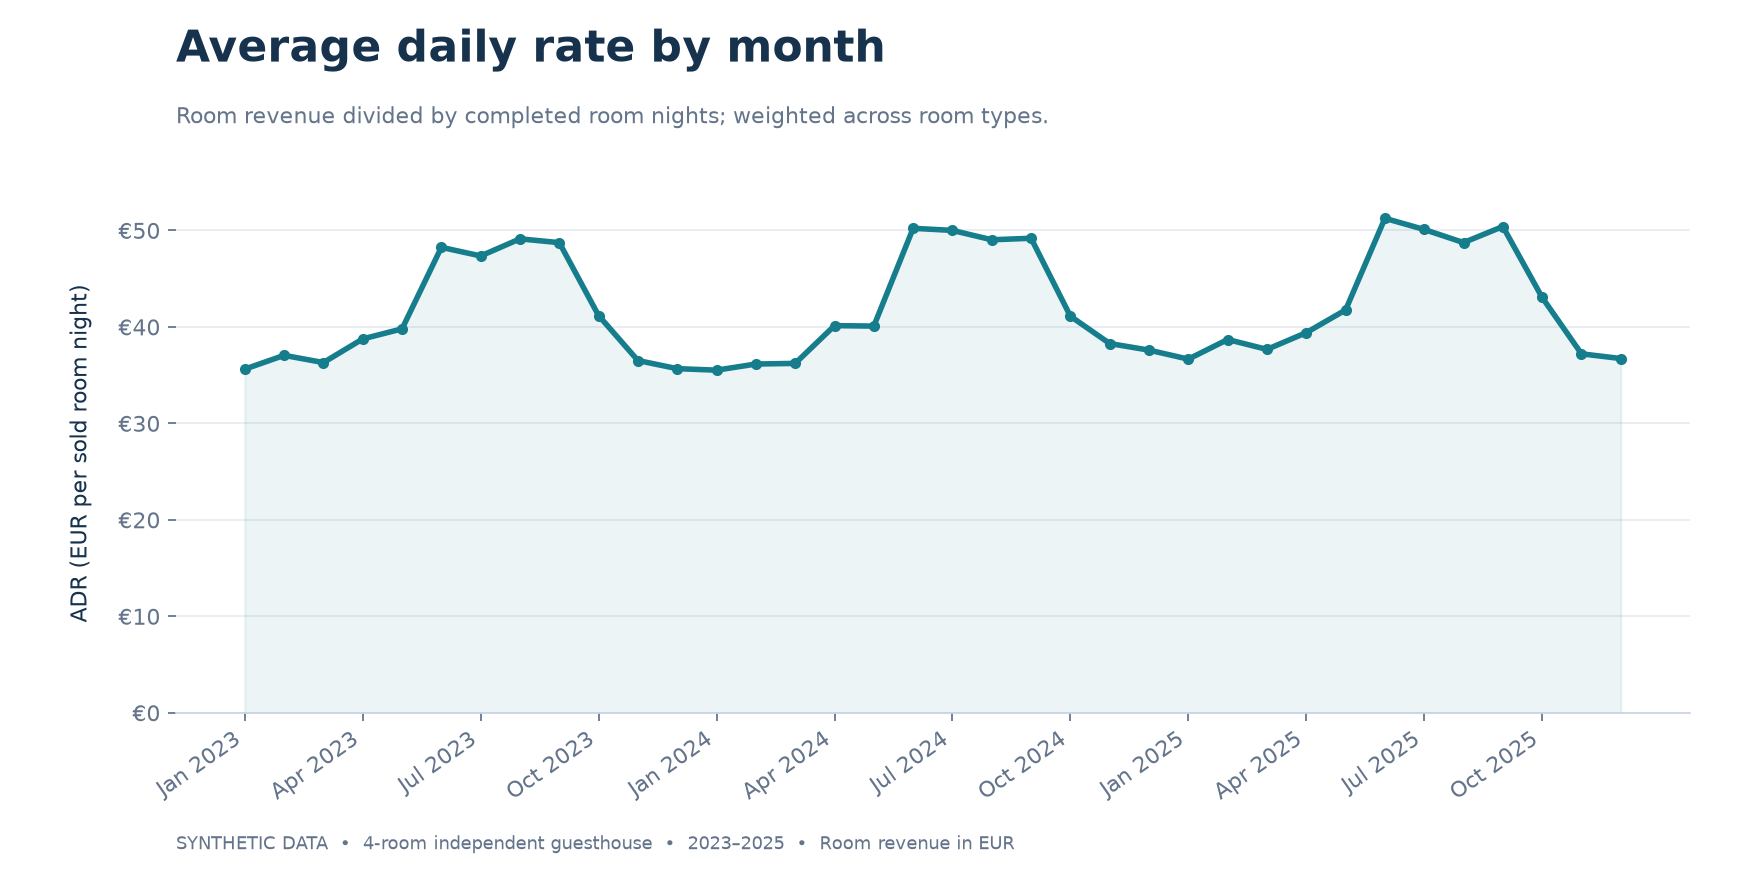

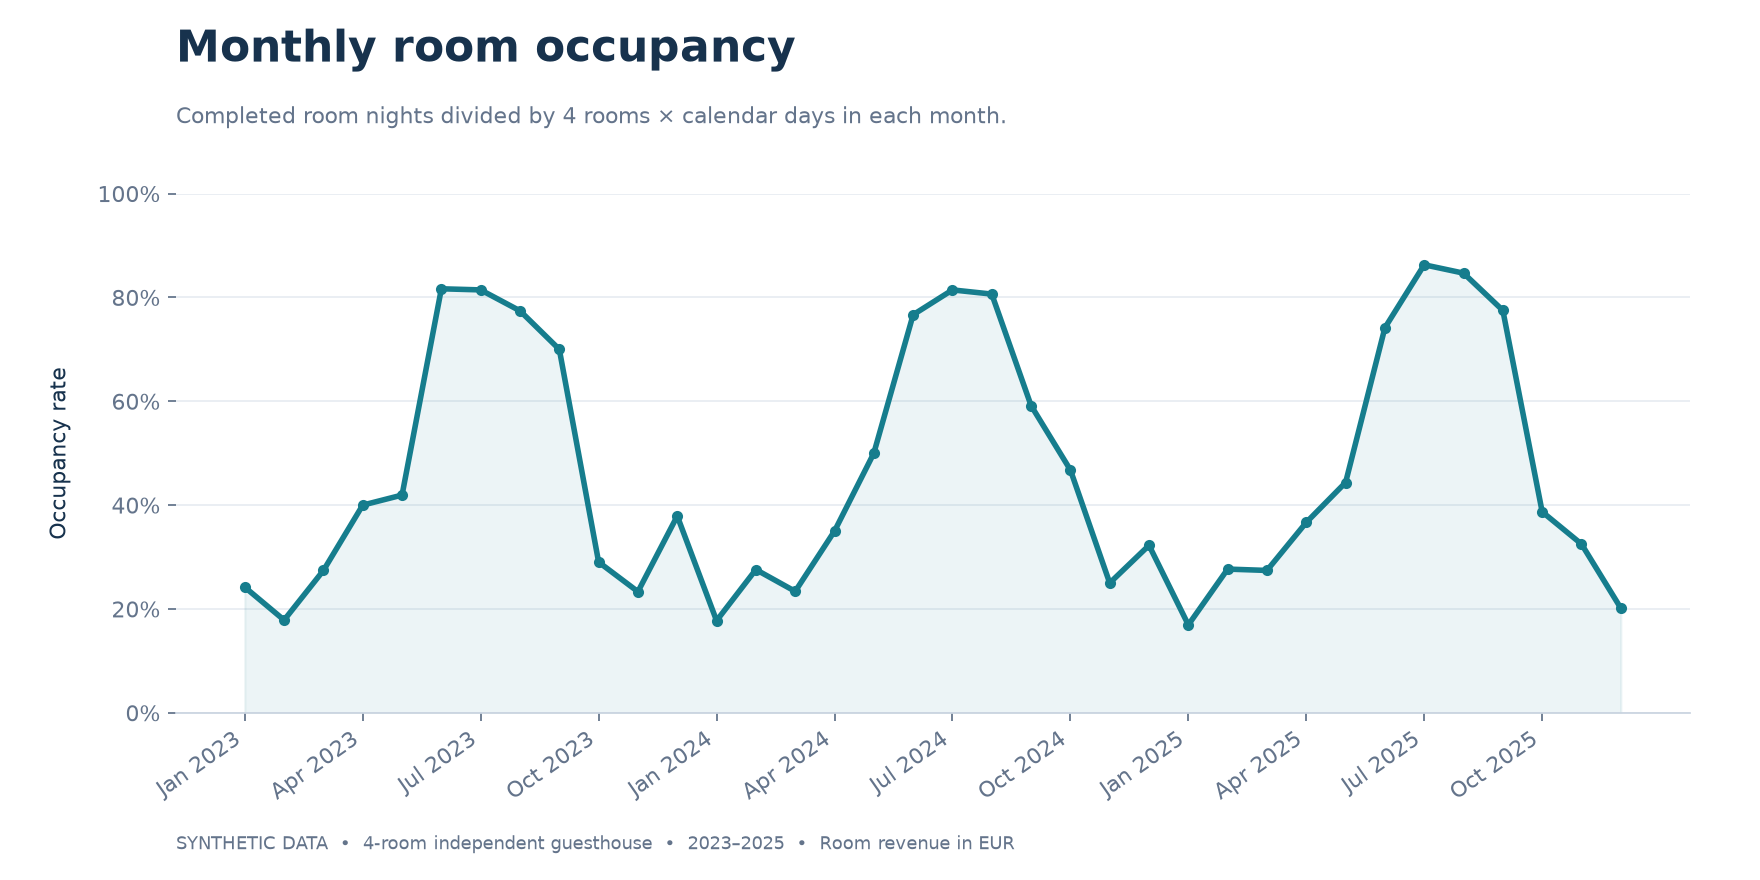

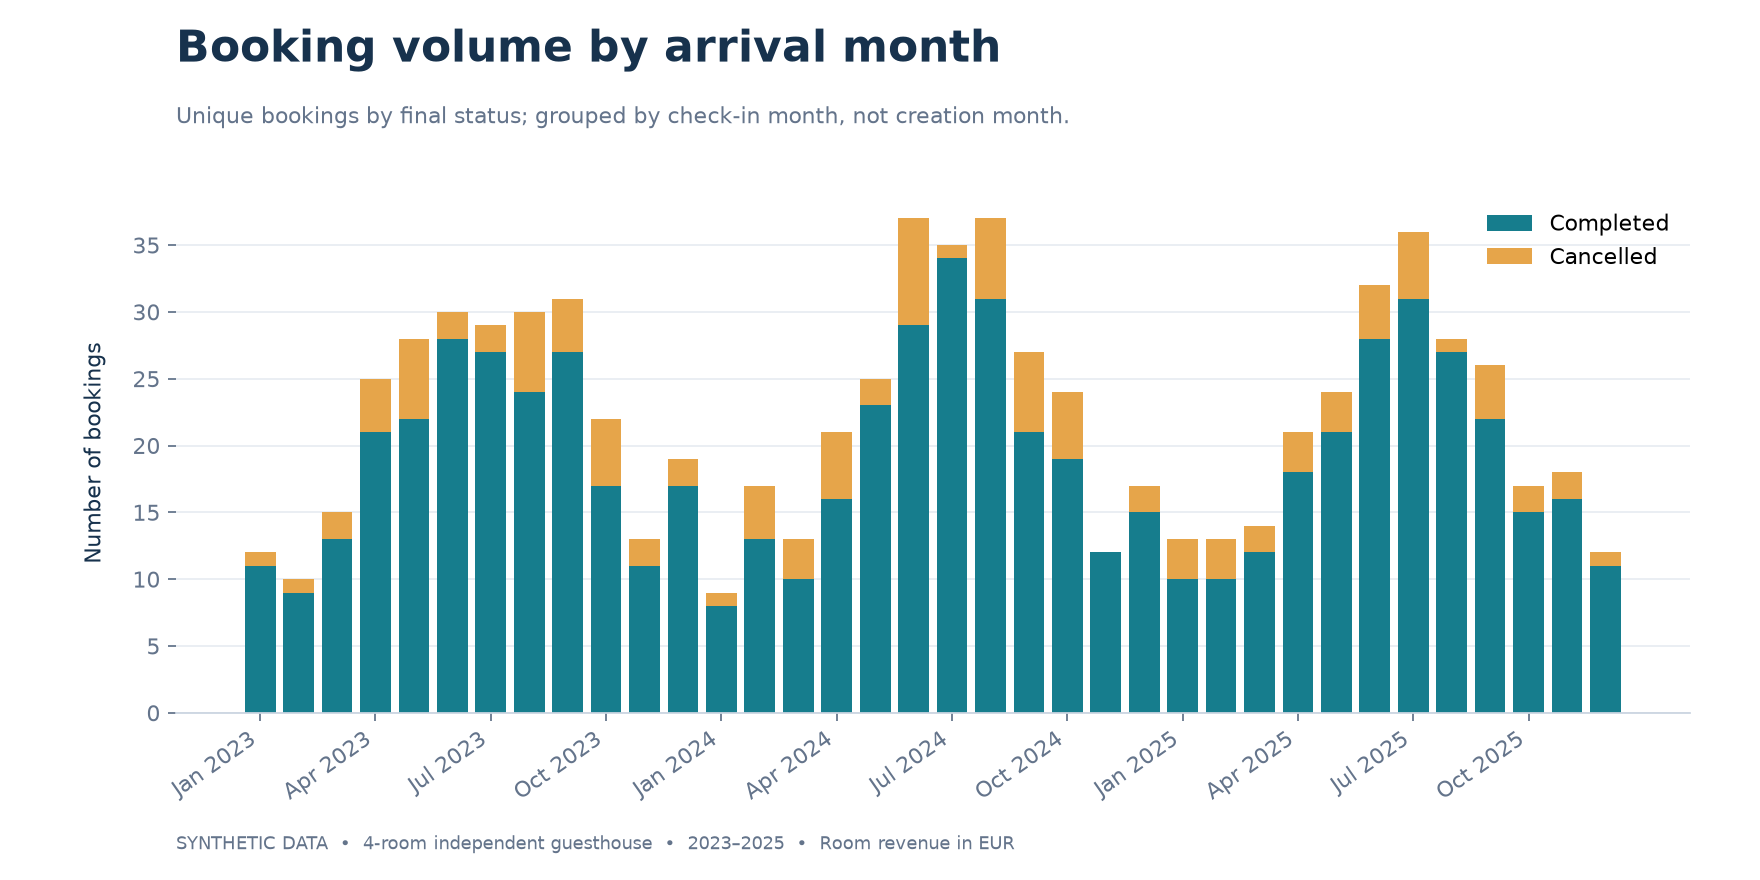

In [6]:
display(tables["monthly_performance"].round(3))
for name in ["monthly_revenue", "monthly_adr", "monthly_occupancy", "monthly_bookings"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 7. Compare room types fairly

Each category has exactly one physical room: Standard Double, Twin Room, Family Room and Superior Double. All four categories have equal available room nights; revenue share reflects achieved prices and sold nights. Small booking samples require care. Occupancy and RevPAR provide useful comparisons alongside revenue, ADR and completed booking volume. This analysis measures gross room revenue, not contribution margin.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,revenue_share,completed_bookings,total_bookings
room_type,,,,,,,,,
Family Room,"24,016.43",510,1096,47.09,0.47,21.91,0.26,171,202
Standard Double,"21,580.87",529,1096,40.80,0.48,19.69,0.24,170,195
Superior Double,"24,680.15",507,1096,48.68,0.46,22.52,0.27,160,189
Twin Room,"20,905.67",498,1096,41.98,0.45,19.07,0.23,178,206


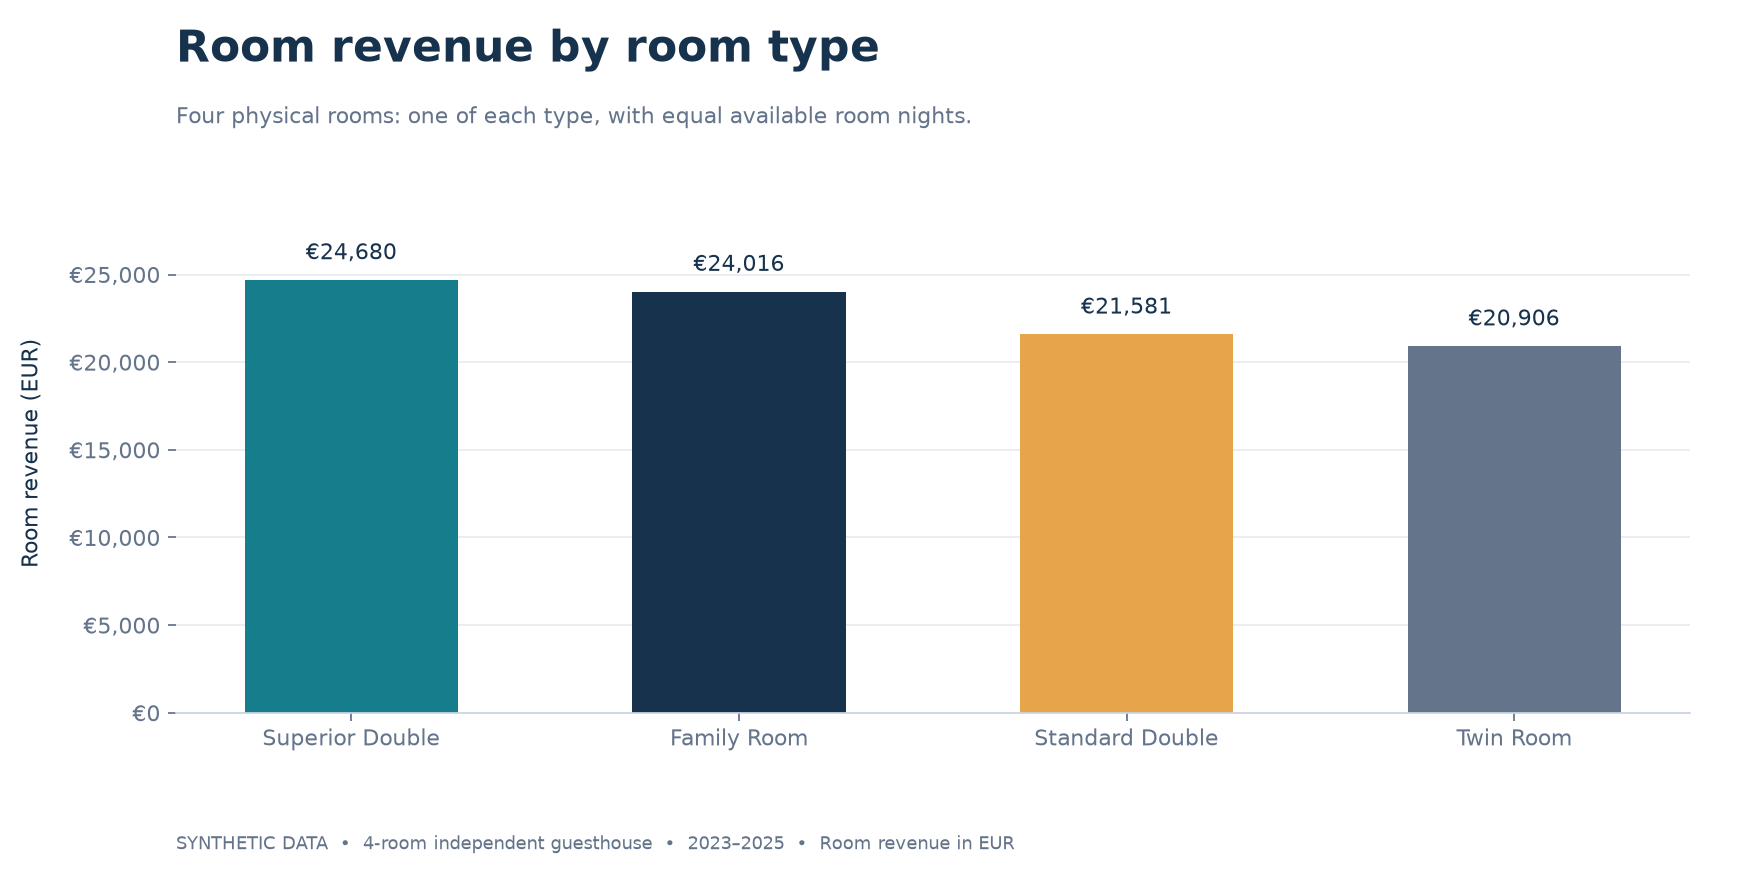

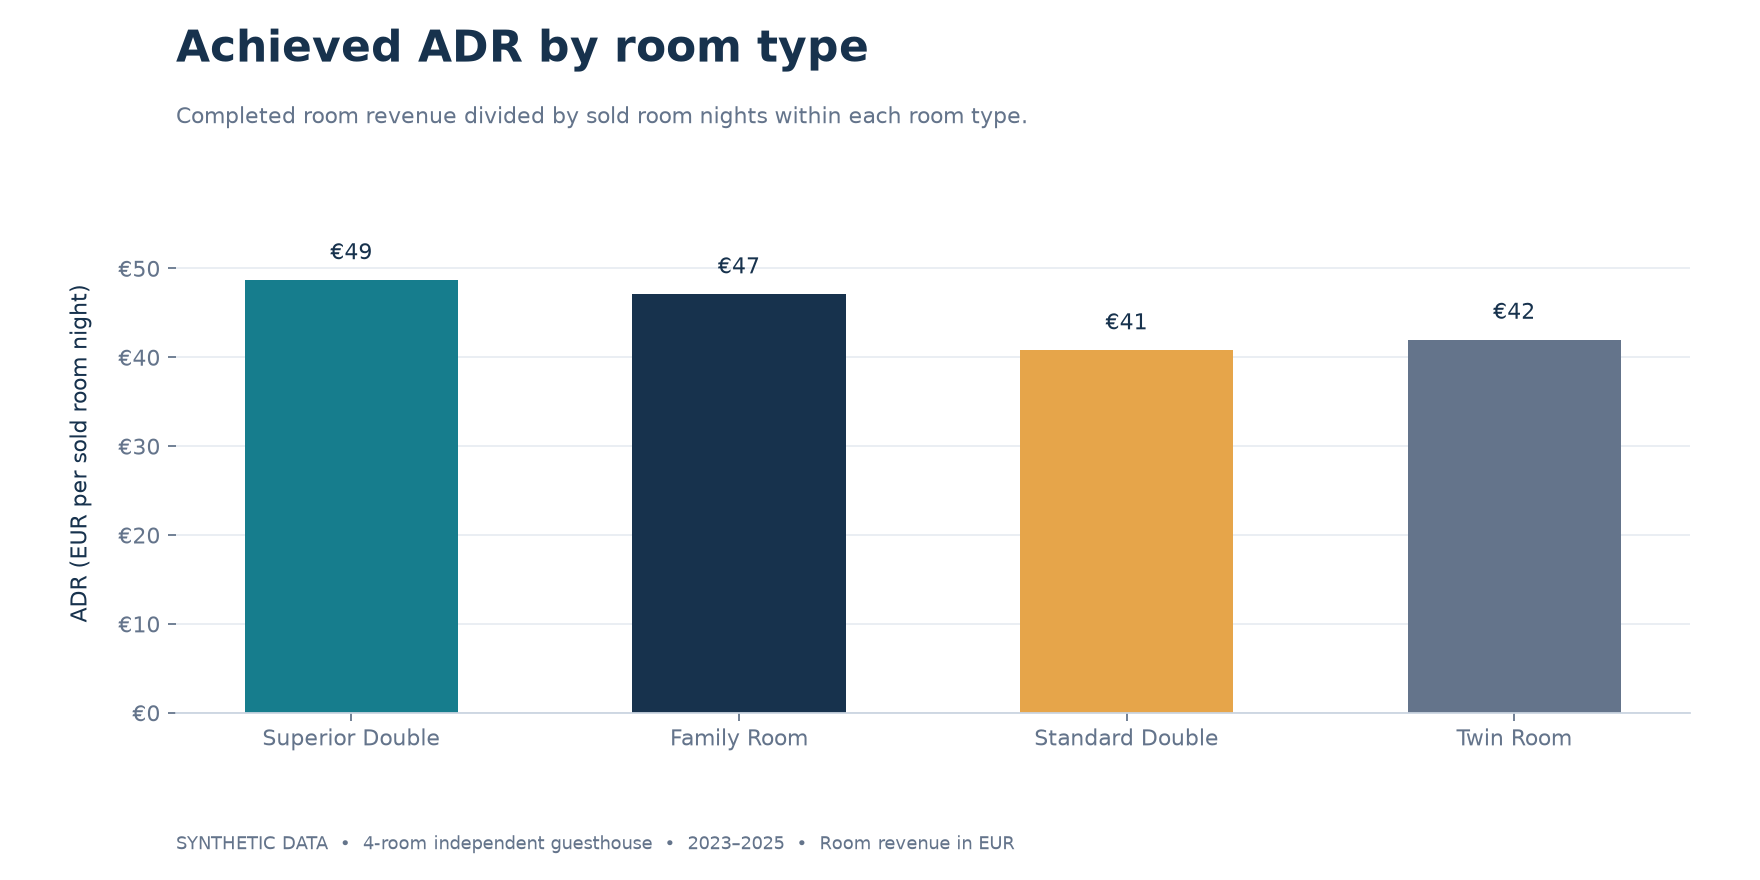

In [7]:
display(tables["room_performance"].round(3))
for name in ["room_type_revenue", "room_type_adr"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 8. Compare seasons and weekdays/weekends

Occupancy adjusts for different numbers of calendar days, including leap years. Weekend means Friday and Saturday stay nights; the other five nights are weekdays. Comparing raw weekend revenue against five weekdays without exposure adjustment would be misleading.

Demand seasons are Low (January–March and November–December), Shoulder (April–May and October), and High (June–September). Booking-level `season` describes arrival. Nightly seasonal revenue follows the actual stay date; a stay crossing a seasonal boundary can contribute to both seasons.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,total_bookings
season,,,,,,,
Low,"17,003.23",462,1816,36.80,0.25,9.36,207
Shoulder,"18,064.41",445,1104,40.59,0.40,16.36,207
High,"56,115.48",1137,1464,49.35,0.78,38.33,378


,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar
month_number,,,,,,
1,"2,620.05",73,372,35.89,0.20,7.04
2,"3,097.47",83,340,37.32,0.24,9.11
3,"3,565.43",97,372,36.76,0.26,9.58
4,"5,279.83",134,360,39.40,0.37,14.67
5,"6,851.55",169,372,40.54,0.45,18.42
6,"13,910.63",279,360,49.86,0.78,38.64
7,"15,193.80",309,372,49.17,0.83,40.84
8,"14,737.13",301,372,48.96,0.81,39.62
9,"12,273.92",248,360,49.49,0.69,34.09


,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar
day_type,,,,,,
Weekday,"63,369.95",1426,3136,44.44,0.46,20.21
Weekend,"27,813.17",618,1248,45.01,0.49,22.29


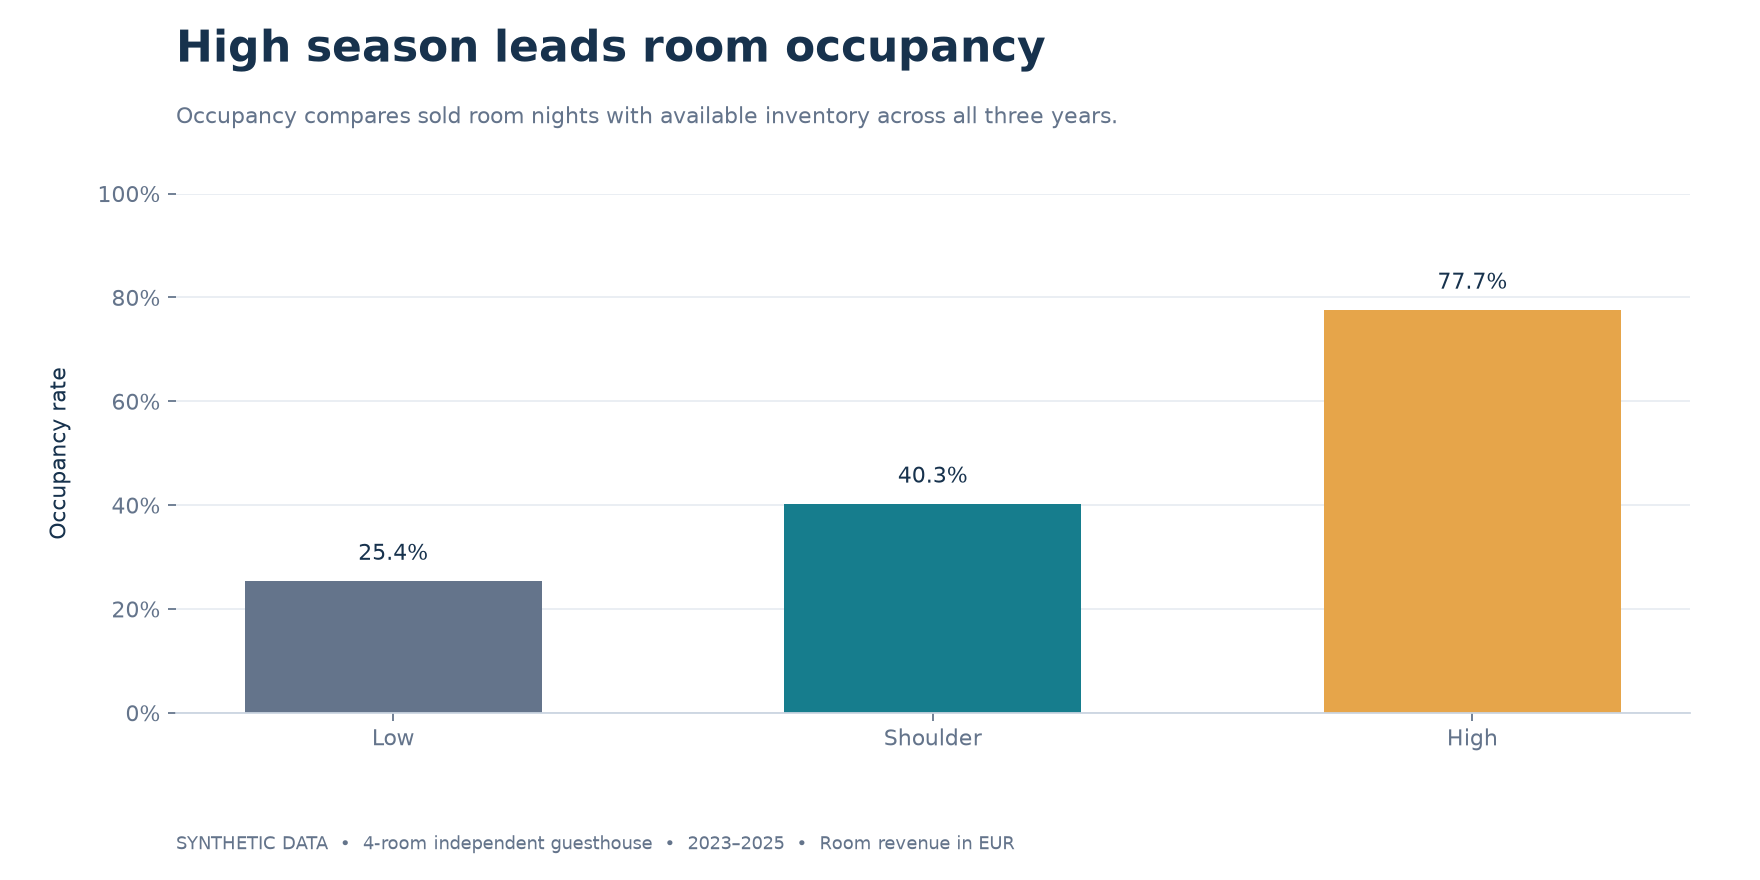

In [8]:
display(tables["seasonal_performance"].round(3))
display(tables["calendar_month_performance"].round(3))
display(tables["weekday_weekend_performance"].round(3))
display(Image(filename=str(FIGURES_DIR / "seasonal_demand.png"), width=880))

## 9. Inspect booking behavior

Lead time is measured for completed bookings. Channel cancellation rates use all unique bookings in each channel. Longer lead times can co-occur with summer demand, so an apparent lead-time pricing pattern can be confounded by season.

Creation-month counts are distinct from arrival-month counts and include some dates in 2022. They are conditioned on arrivals during the study window and should not be interpreted as a complete sales pipeline.

,total_bookings,cancellation_rate
booking_channel,,
Direct,328,0.08
Online travel agency,383,0.19
Travel agent,81,0.18


,nights,lead_time
room_type,,
Family Room,2.98,28.60
Standard Double,3.11,30.23
Superior Double,3.17,30.80
Twin Room,2.80,25.82


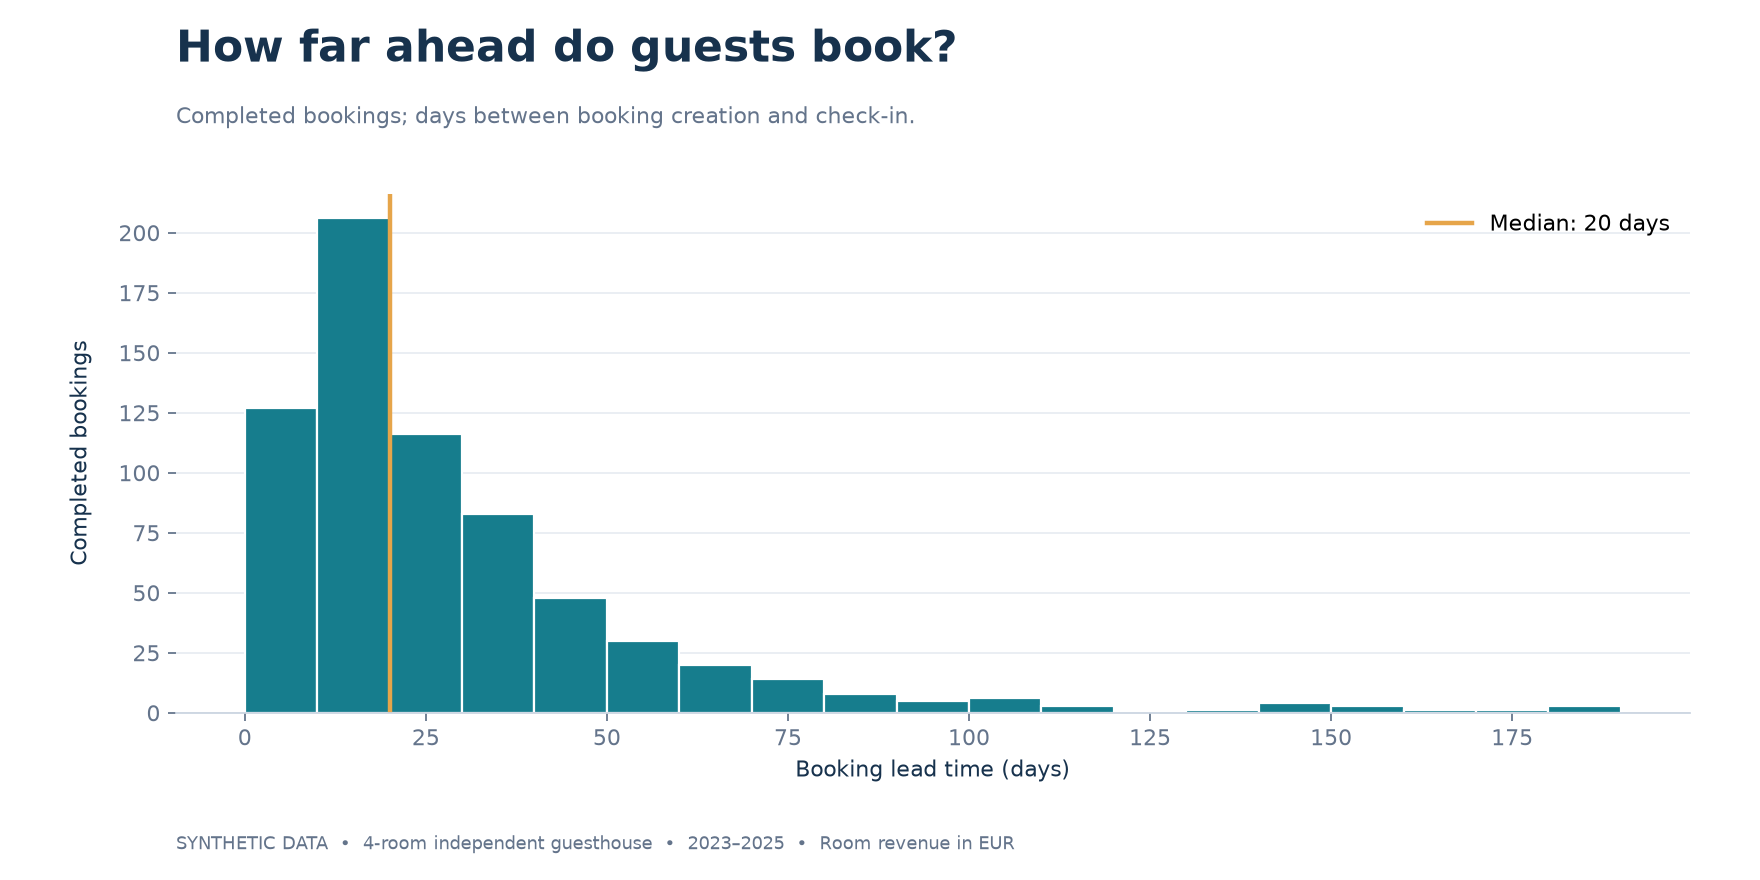

In [9]:
channels = bookings.groupby("booking_channel").agg(
    total_bookings=("booking_id", "size"),
    cancellation_rate=("booking_status", lambda values: values.eq("Cancelled").mean()),
)
display(channels.round(3))
completed = bookings.loc[bookings["booking_status"].eq("Completed")]
display(completed.groupby("room_type")[["nights", "lead_time"]].mean().round(2))
display(Image(filename=str(FIGURES_DIR / "lead_time_distribution.png"), width=880))

## 10. Evaluate pricing relationships

Compare monthly sold room nights and occupancy against ADR, rates across seasons within room type, and lead-time bands within room type. Lead-time ADR is weighted by sold room nights. The tables include sample sizes so sparse comparisons are visible.

**Interpretation limit:** seasonality drives both demand and prices by design. Pearson correlations describe that simulated association; they do not show that increasing prices increases demand. Within-room-type comparisons reduce room-mix distortion but do not eliminate seasonality or other confounding. No price elasticity model or automated dynamic-pricing engine is fitted.

,pearson_r,observations
relationship,,
Monthly occupancy vs ADR,0.95,36
Monthly sold room nights vs ADR,0.94,36
Completed booking lead time vs quoted nightly rate,0.15,679


revenue  room_nights  available_room_nights   adr  \
season   room_type                                                             
High     Family Room     15,181.59          293                    366 51.81   
         Standard Double 13,172.06          292                    366 45.11   
         Superior Double 14,762.34          273                    366 54.08   
         Twin Room       12,999.49          279                    366 46.59   
Low      Family Room      4,243.48          108                    454 39.29   
         Standard Double  4,033.63          120                    454 33.61   
         Superior Double  4,774.55          119                    454 40.12   
         Twin Room        3,951.57          115                    454 34.36   
Shoulder Family Room      4,591.36          109                    276 42.12   
         Standard Double  4,375.18          117                    276 37.40   
         Superior Double  5,143.26          115                    276 44.72   
         Twin Room        3,954.61          104                    276 38.02   

                          occupancy_rate  revpar  
season   room_type                                
High     Family Room                0.80   41.48  
         Standard Double            0.80   35.99  
         Superior Double            0.75   40.33  
         Twin Room                  0.76   35.52  
Low      Family Room                0.24    9.35  
         Standard Double            0.26    8.88  
         Superior Double            0.26   10.52  
         Twin Room                  0.25    8.70  
Shoulder Family Room                0.40   16.64  
         Standard Double            0.42   15.85  
         Superior Double            0.42   18.64  
         Twin Room                  0.38   14.33

completed_bookings  room_nights   revenue  \
room_type       lead_time_band                                              
Family Room     0–7 days                        20           51  2,167.51   
                8–30 days                       95          268 12,479.55   
                31–60 days                      41          137  6,800.71   
                61+ days                        15           54  2,568.66   
Standard Double 0–7 days                        27           88  3,314.51   
                8–30 days                       86          254 10,219.48   
                31–60 days                      38          123  5,408.01   
                61+ days                        19           64  2,638.87   
Superior Double 0–7 days                        11           28  1,209.71   
                8–30 days                       92          299 14,548.68   
                31–60 days                      36           99  5,066.22   
                61+ days                        21           81  3,855.54   
Twin Room       0–7 days                        22           58  2,283.39   
                8–30 days                      107          297 12,421.46   
                31–60 days                      37          114  4,937.23   
                61+ days                        12           29  1,263.59   

                                 adr  
room_type       lead_time_band        
Family Room     0–7 days       42.50  
                8–30 days      46.56  
                31–60 days     49.64  
                61+ days       47.57  
Standard Double 0–7 days       37.66  
                8–30 days      40.23  
                31–60 days     43.97  
                61+ days       41.23  
Superior Double 0–7 days       43.20  
                8–30 days      48.66  
                31–60 days     51.17  
                61+ days       47.60  
Twin Room       0–7 days       39.37  
                8–30 days      41.82  
                31–60 days     43.31  
                61+ days       43.57

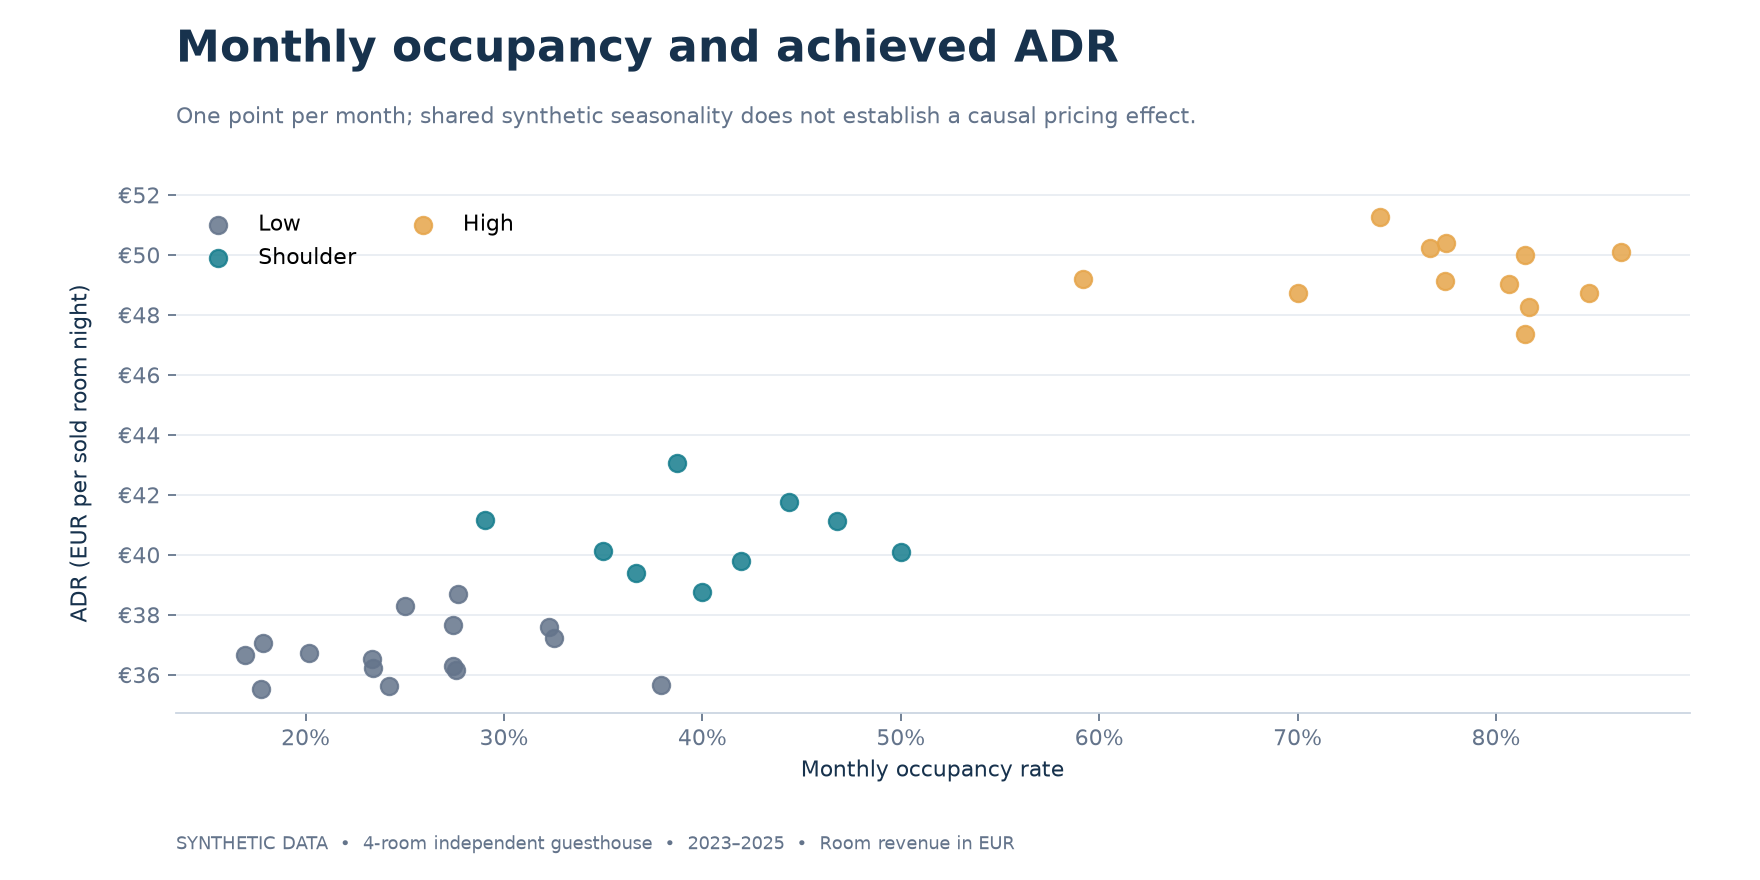

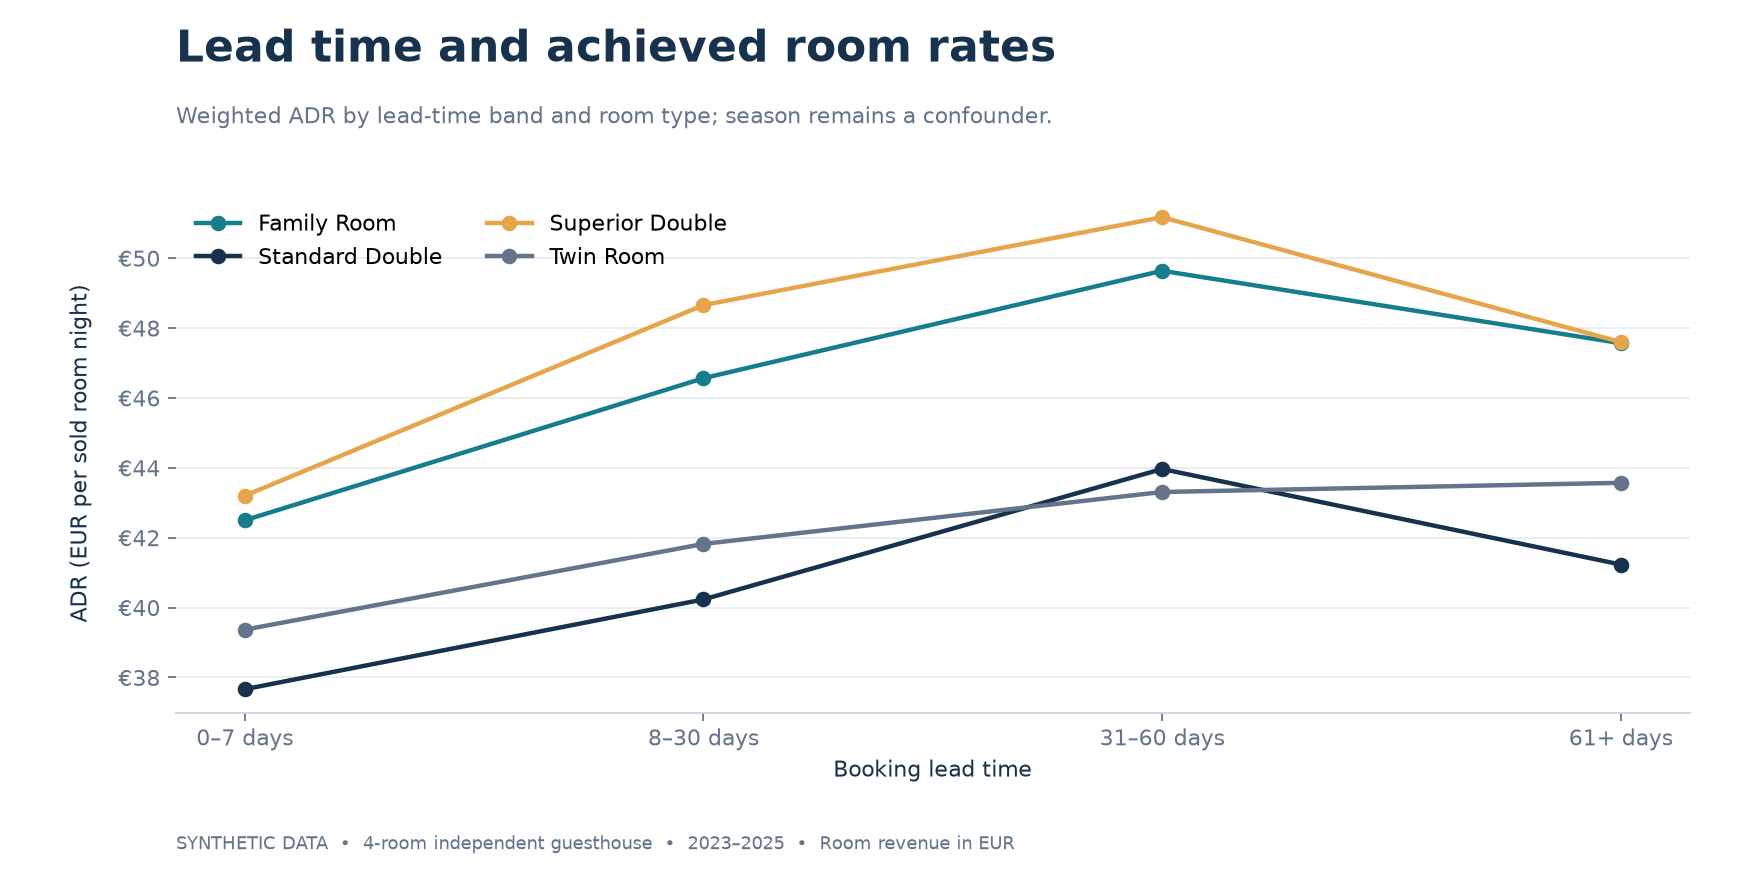

In [10]:
display(tables["pricing_correlations"].round(3))
display(tables["pricing_by_season_room"].round(3))
display(tables["pricing_by_lead_time"].round(3))
for name in ["occupancy_vs_adr", "lead_time_vs_adr"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 11. Turn findings into testable recommendations

The statements below are derived from the current results. High-occupancy pricing and low-occupancy promotion suggestions are conditional, illustrative hypotheses. They do not promise a revenue uplift or claim proven business impact. With only four rooms, one extra occupied room changes daily occupancy by 25 percentage points; review several weeks of comparable dates before acting on small samples.

In [11]:
insights = business_insights(kpis, tables)
display(Markdown("\n\n".join(f"- {insight}" for insight in insights)))

- 2025-07 generated the most monthly room revenue (€5,360.52). Revenue is allocated by stay night, including stays crossing month-end.

- High season had the highest occupancy (77.7%) at €49.35 ADR; low season had the lowest (25.4%) at €36.80 ADR.

- The Superior Double generated 27.1% of room revenue (€24,680.15). Compare its 46.3% occupancy and €22.52 RevPAR alongside revenue share; each category contains exactly one physical room.

- 14.3% of unique bookings were cancelled. Completed stays averaged 3.01 nights and were booked 28.8 days ahead.

- Pricing hypothesis: with high season occupancy at 77.7%, test a €2–€3 nightly increase on selected busy dates, keeping trial quotes within the illustrative €30–€65 range, and monitor enquiries, cancellations and RevPAR. The data does not estimate an optimal price or uplift.

- Promotion hypothesis: low season occupancy of 25.4% suggests testing a modest multi-night offer on specific unsold dates, keeping quoted rates at least €30. Evaluate incremental room nights and net revenue after discount and channel costs, which are not modeled here.

- With four rooms, selling one extra room changes daily occupancy by 25 percentage points. Review comparable dates over several weeks and include booking counts before changing prices; one room type is only one physical room.

- Monthly occupancy and ADR have a Pearson correlation of 0.95. Both share an explicitly programmed seasonal pattern; this is descriptive and cannot show that raising prices causes stronger demand.

## 12. What this project can and cannot demonstrate

The project demonstrates a reproducible cleaning and analytics workflow, correct nightly accounting, defensible capacity denominators, clear visuals and supported business communication. All data and simulation parameters are artificial.

A real follow-up would need authorized inventory availability, cancellation timestamps, channel costs and demand/conversion measures to assess profitability and price sensitivity. Here, costs and rejected demand are unavailable; cancellations never hold inventory; the first day starts without carry-in guests and final-year stays are shortened at the reporting boundary. These choices limit operational realism.

Rebuild all committed outputs with `python -m src.run_analysis`; validate accounting and simulation properties with `python -m unittest discover -s tests -v`.

> This repository contains no real customer, reservation, Booking.com, or business data. All data is synthetically generated for portfolio and demonstration purposes.